<a href="https://colab.research.google.com/github/aansikkaw/Bio-BERT-Medical-Entity-Resolution-Agentic-Healthcare-System/blob/main/finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

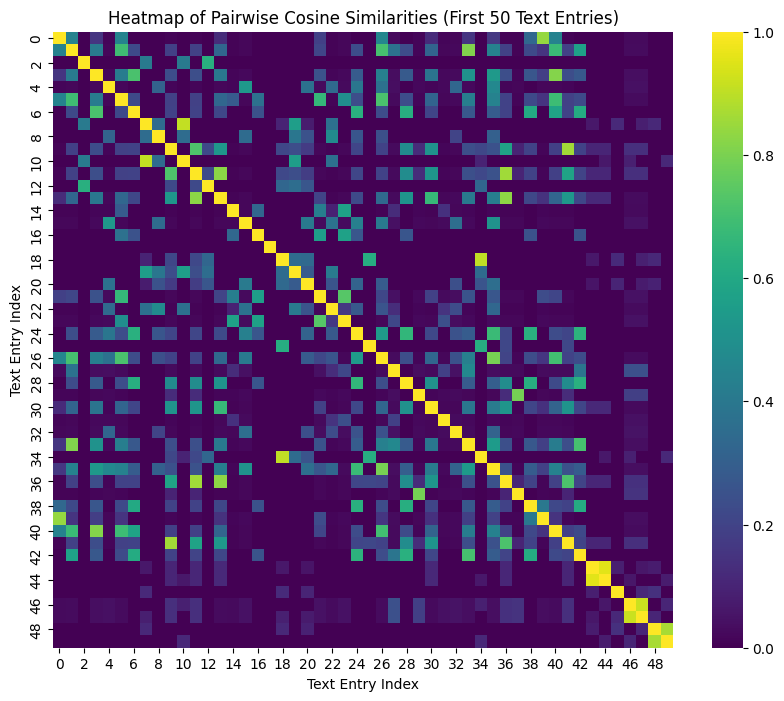

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load the dataset
df = pd.read_csv('dataset 1.csv')

# Compute TF-IDF vectors for the text column
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['Text'])

# Calculate cosine similarity
cosine_similarities = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Select a specific section (first 50 text entries)
section = cosine_similarities[:50, :50]

# Create a heatmap for the selected section
plt.figure(figsize=(10, 8))
sns.heatmap(section, cmap='viridis', annot=False)
plt.title('Heatmap of Pairwise Cosine Similarities (First 50 Text Entries)')
plt.xlabel('Text Entry Index')
plt.ylabel('Text Entry Index')
plt.show()



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import wordnet
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import torch
from torch.utils.data import Dataset

# Download the wordnet data
nltk.download('wordnet')

# Function to get synonyms for words in the text
def get_synonym(text):
    words = text.split()
    synonym_words = []
    for word in words:
        synonyms = wordnet.synsets(word)
        if synonyms:
            synonym = synonyms[0].lemmas()[0].name()
            synonym_words.append(synonym)
        else:
            synonym_words.append(word)
    return ' '.join(synonym_words)

# Load the dataset
df = pd.read_csv('dataset 1.csv')

# Create triplets with synonyms for positive examples
triplets = []

for index, row in df.iterrows():
    anchor = row['Text']
    positive = get_synonym(anchor)  # Generate a synonym text
    negative = df.sample(1).iloc[0]['Text']  # Randomly select a negative example

    triplets.append((anchor, positive, negative))

# Convert triplets to DataFrame
triplet_df = pd.DataFrame(triplets, columns=['anchor', 'positive', 'negative'])

# Split the data into training and validation sets
train_df, val_df = train_test_split(triplet_df, test_size=0.2, random_state=42)

# Save the triplet datasets to CSV files
train_df.to_csv('train_triplets_with_synonyms.csv', index=False)
val_df.to_csv('val_triplets_with_synonyms.csv', index=False)

# Custom Dataset class for triplet data
class TripletDataset(Dataset):
    def __init__(self, dataframe, tokenizer):
        self.dataframe = dataframe
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        anchor = self.dataframe.iloc[idx]['anchor']
        positive = self.dataframe.iloc[idx]['positive']
        negative = self.dataframe.iloc[idx]['negative']

        anchor_encodings = self.tokenizer(anchor, truncation=True, padding='max_length', max_length=128)
        positive_encodings = self.tokenizer(positive, truncation=True, padding='max_length', max_length=128)
        negative_encodings = self.tokenizer(negative, truncation=True, padding='max_length', max_length=128)

        return {
            'anchor_input_ids': torch.tensor(anchor_encodings['input_ids']),
            'anchor_attention_mask': torch.tensor(anchor_encodings['attention_mask']),
            'positive_input_ids': torch.tensor(positive_encodings['input_ids']),
            'positive_attention_mask': torch.tensor(positive_encodings['attention_mask']),
            'negative_input_ids': torch.tensor(negative_encodings['input_ids']),
            'negative_attention_mask': torch.tensor(negative_encodings['attention_mask'])
        }



[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
model_name = "dmis-lab/biobert-base-cased-v1.1"

In [ ]:
from transformers import AutoModel, AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

In [ ]:
from torch import nn
class BertEmbeddingsModel(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state[:, 0, :]

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
EPOCHS = 3
LR = 5e-5

In [ ]:
from torch import nn
# Initialize the tokenizer
tokenizer = BertTokenizer.from_pretrained(model_name)

# Create the datasets
train_dataset = TripletDataset(train_df, tokenizer)
val_dataset = TripletDataset(val_df, tokenizer)

dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)


model = BertEmbeddingsModel(model_name).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
triplet_loss = nn.TripletMarginLoss(margin=1.0, p =2)


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

In [ ]:
model.train()

BertEmbeddingsModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, eleme

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import wordnet
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import torch
from torch.utils.data import Dataset
from torch import nn # Import nn here as well

# Download the wordnet data
nltk.download('wordnet')

# Function to get synonyms for words in the text (Assuming this is correct)
def get_synonym(text):
    words = text.split()
    synonym_words = []
    for word in words:
        synonyms = wordnet.synsets(word)
        if synonyms:
            synonym = synonyms[0].lemmas()[0].name()
            synonym_words.append(synonym)
        else:
            synonym_words.append(word)
    return ' '.join(synonym_words)

# Load the dataset (Assuming 'dataset 1.csv' exists)
try:
    df = pd.read_csv('dataset 1.csv')
except FileNotFoundError:
    print("Error: 'dataset 1.csv' not found. Please make sure the dataset file is in the correct directory.")
    # Create a dummy dataframe for demonstration if file is missing
    df = pd.DataFrame({'Text': ['This is sentence one.', 'This is sentence two.', 'Another sentence here.', 'Yet another text entry.']})


# Create triplets with synonyms for positive examples
triplets = []

for index, row in df.iterrows():
    anchor = row['Text']
    positive = get_synonym(anchor)  # Generate a synonym text
    # Handle potential errors if sample(1) returns an empty dataframe
    if not df.empty:
        negative = df.sample(1).iloc[0]['Text']  # Randomly select a negative example
    else:
        negative = "Default negative text if df is empty" # Or handle as needed

    triplets.append((anchor, positive, negative))

# Convert triplets to DataFrame
triplet_df = pd.DataFrame(triplets, columns=['anchor', 'positive', 'negative'])

# Split the data into training and validation sets
train_df, val_df = train_test_split(triplet_df, test_size=0.2, random_state=42)

# Save the triplet datasets to CSV files
train_df.to_csv('train_triplets_with_synonyms.csv', index=False)
val_df.to_csv('val_triplets_with_synonyms.csv', index=False)


# Custom Dataset class for triplet data
class TripletDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.dataframe = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        anchor = self.dataframe.iloc[idx]['anchor']
        positive = self.dataframe.iloc[idx]['positive']
        negative = self.dataframe.iloc[idx]['negative']

        # Tokenize and convert to tensors within __getitem__
        anchor_encodings = self.tokenizer(anchor, truncation=True, padding='max_length', max_length=self.max_length, return_tensors='pt')
        positive_encodings = self.tokenizer(positive, truncation=True, padding='max_length', max_length=self.max_length, return_tensors='pt')
        negative_encodings = self.tokenizer(negative, truncation=True, padding='max_length', max_length=self.max_length, return_tensors='pt')

        return {
            'anchor_input_ids': anchor_encodings['input_ids'].squeeze(0), # Squeeze to remove the batch dimension added by return_tensors='pt'
            'anchor_attention_mask': anchor_encodings['attention_mask'].squeeze(0),
            'positive_input_ids': positive_encodings['input_ids'].squeeze(0),
            'positive_attention_mask': positive_encodings['attention_mask'].squeeze(0),
            'negative_input_ids': negative_encodings['input_ids'].squeeze(0),
            'negative_attention_mask': negative_encodings['attention_mask'].squeeze(0)
        }

# Assuming BertEmbeddingsModel class is defined as before
# import torch.nn as nn # Make sure nn is imported for BertEmbeddingsModel

class BertEmbeddingsModel(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        # Import AutoModel here to ensure it's available
        from transformers import AutoModel
        self.bert = AutoModel.from_pretrained(model_name)
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # Extract the CLS token embedding
        return outputs.last_hidden_state[:, 0, :]


# Assuming necessary variables are defined:
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# BATCH_SIZE = 16
# EPOCHS = 3
# LR = 5e-5
# model_name = "dmis-lab/biobert-base-cased-v1.1"

# Re-initialize tokenizer, datasets, dataloader, model, optimizer, and loss
tokenizer = BertTokenizer.from_pretrained(model_name)
train_dataset = TripletDataset(train_df, tokenizer)
val_dataset = TripletDataset(val_df, tokenizer)

# No custom collate_fn needed now
dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Initialize model, optimizer, and loss function
model = BertEmbeddingsModel(model_name).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
triplet_loss = nn.TripletMarginLoss(margin=1.0, p=2) # Use p=2 for Euclidean distance squared


# Training loop (keep the loop as it is, it should now receive batches of tensors)
from tqdm import tqdm

model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    print(f"Epoch {epoch + 1}/{EPOCHS}")

    for batch in tqdm(dataloader):
        # The batch should now be a dictionary with the correct keys and stacked tensors
        # print(batch.keys())
        # print(type(batch))

        # Move tensors to the correct device
        anchor_input_ids = batch['anchor_input_ids'].to(DEVICE)
        anchor_attention_mask = batch['anchor_attention_mask'].to(DEVICE)
        positive_input_ids = batch['positive_input_ids'].to(DEVICE)
        positive_attention_mask = batch['positive_attention_mask'].to(DEVICE)
        negative_input_ids = batch['negative_input_ids'].to(DEVICE)
        negative_attention_mask = batch['negative_attention_mask'].to(DEVICE)

        optimizer.zero_grad()

        # Pass input_ids and attention_mask to the model
        anchor_embeddings = model(anchor_input_ids, anchor_attention_mask)
        positive_embeddings = model(positive_input_ids, positive_attention_mask)
        negative_embeddings = model(negative_input_ids, negative_attention_mask)

        loss = triplet_loss(anchor_embeddings, positive_embeddings, negative_embeddings)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Average Loss: {avg_loss:.4f}")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Epoch 1/3


100%|██████████| 102/102 [01:25<00:00,  1.19it/s]


Average Loss: 0.0071
Epoch 2/3


100%|██████████| 102/102 [01:28<00:00,  1.15it/s]


Average Loss: 0.0042
Epoch 3/3


100%|██████████| 102/102 [01:30<00:00,  1.12it/s]

Average Loss: 0.0035


In [ ]:
from torch.nn.functional import cosine_similarity

def compute_cosine_similarity(a, b):
    return cosine_similarity(a, b).squeeze().cpu().item()






In [ ]:
from torch import nn
from torch.nn.functional import cosine_similarity
from tqdm import tqdm
import pandas as pd
import torch
from transformers import BertTokenizer # Import BertTokenizer if not already imported

# Assuming BertEmbeddingsModel and TripletDataset classes are defined in previous cells
# Assuming train_df, val_df, model_name, DEVICE are defined in previous cells

def compute_cosine_similarity(a, b):
    # Ensure tensors are flattened if necessary before calculating cosine similarity
    # This handles cases where embeddings might have an extra dimension (e.g., Batch size 1)
    if a.dim() > 1:
        a = a.view(-1)
    if b.dim() > 1:
        b = b.view(-1)
    return cosine_similarity(a, b, dim=0).cpu().item()


def evaluate_triplets(model, triplet_df, tokenizer, sample_size=10):
    model.eval()
    # Handle cases where sample_size is larger than the dataframe size
    sample_size = min(sample_size, len(triplet_df))
    samples = triplet_df.sample(sample_size)
    correct = 0

    print("\nEvaluation Samples:\n")

    for index, row in samples.iterrows():
        # Tokenize inputs for the BertEmbeddingsModel
        # Ensure return_tensors='pt' is used
        anchor_inputs = tokenizer(row['anchor'], return_tensors='pt', truncation=True, padding='max_length', max_length=128).to(DEVICE)
        positive_inputs = tokenizer(row['positive'], return_tensors='pt', truncation=True, padding='max_length', max_length=128).to(DEVICE)
        negative_inputs = tokenizer(row['negative'], return_tensors='pt', truncation=True, padding='max_length', max_length=128).to(DEVICE)

        with torch.no_grad():
            # Use the forward method of BertEmbeddingsModel, which expects input_ids and attention_mask
            # Pass inputs as keyword arguments
            anchor_emb = model(input_ids=anchor_inputs['input_ids'], attention_mask=anchor_inputs['attention_mask'])
            positive_emb = model(input_ids=positive_inputs['input_ids'], attention_mask=positive_inputs['attention_mask'])
            negative_emb = model(input_ids=negative_inputs['input_ids'], attention_mask=negative_inputs['attention_mask'])

        pos_sim = compute_cosine_similarity(anchor_emb, positive_emb)
        neg_sim = compute_cosine_similarity(anchor_emb, negative_emb)

        if pos_sim > neg_sim:
            correct += 1

        print(f"Anchor: {row['anchor']}")
        print(f"Positive Similarity: {pos_sim:.4f}")
        print(f"Negative Similarity: {neg_sim:.4f}")
        print("-" * 50)

    accuracy = correct / sample_size
    print(f"\nAccuracy: {accuracy:.4f}")

# Assuming 'model' here refers to the trained BertEmbeddingsModel instance
# Assuming 'triplet_df' is the dataframe containing the triplets
# Assuming 'tokenizer' is the BertTokenizer instance used for training
evaluate_triplets(model, triplet_df, tokenizer)


Evaluation Samples:

Anchor: Other procedures on eustachian tube, bilateral
Positive Similarity: 0.9853
Negative Similarity: 0.7510
--------------------------------------------------
Anchor: Reconstruction of pyloroplasty
Positive Similarity: 1.0000
Negative Similarity: 0.5975
--------------------------------------------------
Anchor: Carotid bypass using synthetic material, bilateral
Positive Similarity: 0.9543
Negative Similarity: 0.7708
--------------------------------------------------
Anchor: Repair of traumatic deep, multiple lacerations of liver
Positive Similarity: 0.9963
Negative Similarity: 0.6308
--------------------------------------------------
Anchor: Labyrinthotomy, bilateral
Positive Similarity: 1.0000
Negative Similarity: 0.7076
--------------------------------------------------
Anchor: Excision of retroperitoneal neuro-endocrine lesion with retroperitoneal dissection
Positive Similarity: 0.9717
Negative Similarity: 0.6503
---------------------------------------------

Generating Embeddings for PCA: 100%|██████████| 7/7 [00:03<00:00,  1.88it/s]


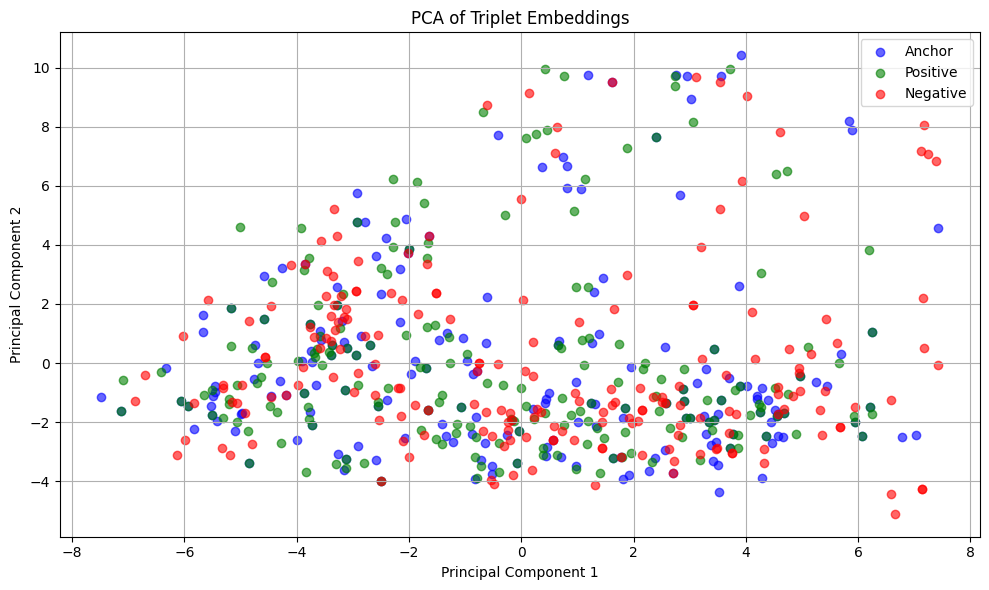

In [ ]:
# Install necessary libraries if not already installed
!pip install scikit-learn matplotlib numpy

# Import necessary libraries
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import torch

# Assuming the trained 'model', 'tokenizer', 'train_df', 'DEVICE' are available from previous cells

# Function to get embeddings for a given dataframe
def get_embeddings_for_pca(model, tokenizer, dataframe, device, max_length=128):
    model.eval() # Set model to evaluation mode
    embeddings = []
    # Create a DataLoader for the dataframe
    pca_dataset = TripletDataset(dataframe, tokenizer, max_length=max_length)
    pca_dataloader = torch.utils.data.DataLoader(pca_dataset, batch_size=32, shuffle=False) # Use a batch size suitable for your memory

    with torch.no_grad():
        for batch in tqdm(pca_dataloader, desc="Generating Embeddings for PCA"):
            anchor_input_ids = batch['anchor_input_ids'].to(device)
            anchor_attention_mask = batch['anchor_attention_mask'].to(device)
            positive_input_ids = batch['positive_input_ids'].to(device)
            positive_attention_mask = batch['positive_attention_mask'].to(device)
            negative_input_ids = batch['negative_input_ids'].to(device)
            negative_attention_mask = batch['negative_attention_mask'].to(device)

            anchor_emb = model(anchor_input_ids, anchor_attention_mask).cpu().numpy()
            positive_emb = model(positive_input_ids, positive_attention_mask).cpu().numpy()
            negative_emb = model(negative_input_ids, negative_attention_mask).cpu().numpy()

            embeddings.append((anchor_emb, positive_emb, negative_emb))

    # Concatenate embeddings from all batches
    anchor_embs = np.vstack([emb[0] for emb in embeddings])
    positive_embs = np.vstack([emb[1] for emb in embeddings])
    negative_embs = np.vstack([emb[2] for emb in embeddings])

    return anchor_embs, positive_embs, negative_embs

# Get embeddings for a portion of the training data for visualization
# You can adjust the size of the sample dataframe as needed
sample_df_for_pca = train_df.sample(min(200, len(train_df)), random_state=42) # Use a smaller sample for PCA visualization

anchor_embs, positive_embs, negative_embs = get_embeddings_for_pca(model, tokenizer, sample_df_for_pca, DEVICE)

# PCA
# Check if there are enough samples for PCA (n_components <= n_samples)
n_samples = len(anchor_embs)
if n_samples < 2:
    print("Not enough samples to perform PCA with 2 components.")
else:
    pca = PCA(n_components=3)
    all_embs = np.vstack([anchor_embs, positive_embs, negative_embs])
    pca_result = pca.fit_transform(all_embs)

    # Split PCA results
    n = len(anchor_embs)
    anchor_pca = pca_result[:n]
    positive_pca = pca_result[n:2*n]
    negative_pca = pca_result[2*n:]

    # Plot
    plt.figure(figsize=(10, 6))
    plt.scatter(anchor_pca[:, 0], anchor_pca[:, 1], label='Anchor', alpha=0.6, c='blue')
    plt.scatter(positive_pca[:, 0], positive_pca[:, 1], label='Positive', alpha=0.6, c='green')
    plt.scatter(negative_pca[:, 0], negative_pca[:, 1], label='Negative', alpha=0.6, c='red')
    plt.title("PCA of Triplet Embeddings")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

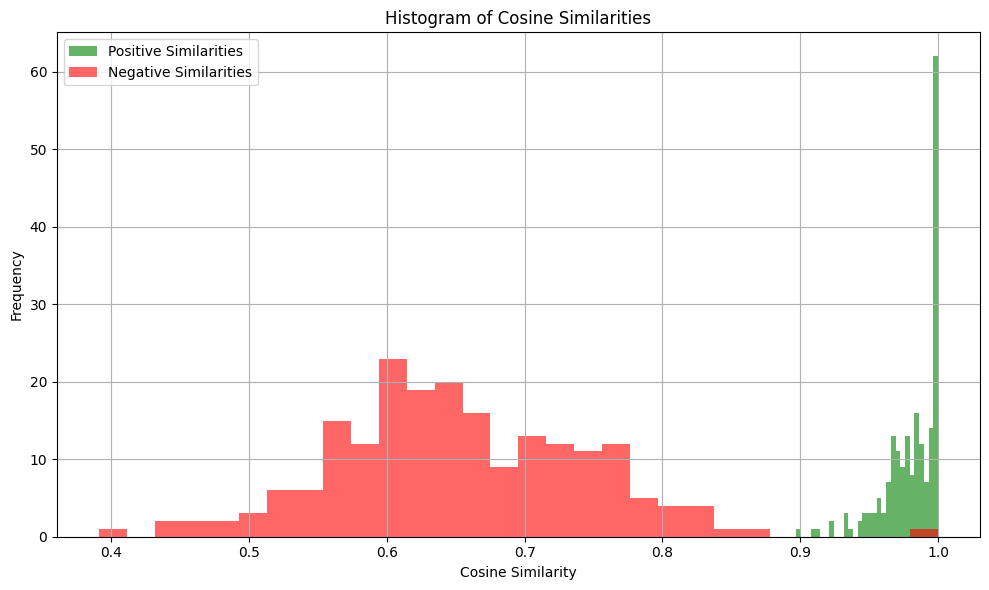

In [ ]:

# Compute cosine similarities
positive_similarities = [cosine_similarity(torch.tensor(a), torch.tensor(p), dim=0).item() for a, p in zip(anchor_embs, positive_embs)]
negative_similarities = [cosine_similarity(torch.tensor(a), torch.tensor(n), dim=0).item() for a, n in zip(anchor_embs, negative_embs)]

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(positive_similarities, bins=30, alpha=0.6, label='Positive Similarities', color='green')
plt.hist(negative_similarities, bins=30, alpha=0.6, label='Negative Similarities', color='red')
plt.title("Histogram of Cosine Similarities")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
pip install huggingface_hub

In [ ]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    A token is already saved on your machine. Run `huggingface-cli whoami` to get more information or `huggingface-cli logout` if you want to log out.
    Setting a new token will erase the existing one.
    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) n
Token is valid (permission: write

In [ ]:
# Save the wrapped Hugging Face model
model.bert.save_pretrained("model_name")
tokenizer.save_pretrained("model_name")


('model_name/tokenizer_config.json',
 'model_name/special_tokens_map.json',
 'model_name/vocab.txt',
 'model_name/added_tokens.json')

In [ ]:
from huggingface_hub import HfApi

# Optional: create a new repo
api = HfApi()

repo_id = "Aan23legend/biobert_base_cased_v1_1_dmis_lab"


# Push model
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_name = "model_name"
model = AutoModelForSequenceClassification.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

model.push_to_hub(repo_id)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at model_name and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/Aan23legend/biobert_base_cased_v1_1_dmis_lab/commit/32fed89882120359a1bf6d4a0452bace0b6dfc10', commit_message='Upload BertForSequenceClassification', commit_description='', oid='32fed89882120359a1bf6d4a0452bace0b6dfc10', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Aan23legend/biobert_base_cased_v1_1_dmis_lab', endpoint='https://huggingface.co', repo_type='model', repo_id='Aan23legend/biobert_base_cased_v1_1_dmis_lab'), pr_revision=None, pr_num=None)

In [ ]:

tokenizer.push_to_hub(repo_id)


No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/Aan23legend/biobert_base_cased_v1_1_dmis_lab/commit/32fed89882120359a1bf6d4a0452bace0b6dfc10', commit_message='Upload tokenizer', commit_description='', oid='32fed89882120359a1bf6d4a0452bace0b6dfc10', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Aan23legend/biobert_base_cased_v1_1_dmis_lab', endpoint='https://huggingface.co', repo_type='model', repo_id='Aan23legend/biobert_base_cased_v1_1_dmis_lab'), pr_revision=None, pr_num=None)

In [ ]:
!pip install chromadb
import pandas as pd
from sentence_transformers import SentenceTransformer, util
import chromadb
from chromadb.config import Settings # Settings might still be needed for other configs, but not for persist_directory and impl

# Load the dataset
df = pd.read_csv("dataset 1.csv")

# Load Sentence-BERT model
model = SentenceTransformer("sentence-transformers/bert-base-nli-mean-tokens")

# Generate embeddings
texts = df["Text"].tolist()
embeddings = model.encode(texts, convert_to_tensor=True)

# Initialize ChromaDB using PersistentClient
# The persist_directory is now passed directly to PersistentClient
client = chromadb.PersistentClient(path="./chroma_db")
collection = client.get_or_create_collection(name="medical_procedures")

# Store embeddings
collection.add(
    documents=texts,
    embeddings=embeddings.tolist(),
    ids=[str(i) for i in range(len(texts))]
)

# Evaluate accuracy using reverse lookup
accuracy = []
for i, embedding in enumerate(embeddings):
    # Query with the embedding. It returns the top n_results most similar results.
    # Since we add each document with its index as the ID, the correct match should
    # have the same index.
    results = collection.query(
        query_embeddings=[embedding.tolist()],
        n_results=1,
        include=['distances'] # Optionally include distances to verify similarity
    )

    # The query returns a list of results for each query embedding (we have one).
    # The 'ids' key contains a list of lists, e.g., [['0']].
    # We expect the top result's ID to be the string representation of the original index i.
    if results and results.get("ids") and results["ids"][0]:
        best_match_id = int(results["ids"][0][0])
        accuracy.append(best_match_id == i)
    else:
        # Handle cases where no results are returned (shouldn't happen with n_results=1 if data exists)
        accuracy.append(False)


# Add accuracy column
df["Accuracy"] = accuracy

# Save updated dataset
df.to_csv("updated_dataset3.csv", index=False)
print("Updated dataset saved as 'updated_dataset3.csv'")

Updated dataset saved as 'updated_dataset3.csv'


In [ ]:
import pandas as pd
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
import chromadb
from chromadb.config import Settings
from torch.utils.data import Dataset, DataLoader # Import DataLoader

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define your BertEmbeddingsModel class (assuming it's the same as in your notebook)
class BertEmbeddingsModel(torch.nn.Module):
    def __init__(self, model_name):
        super().__init__()
        # Import AutoModel here to ensure it's available
        from transformers import AutoModel
        self.bert = AutoModel.from_pretrained(model_name)
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # Extract the CLS token embedding
        return outputs.last_hidden_state[:, 0, :]

# Load the dataset
df = pd.read_csv("dataset 1.csv")

# Load your fine-tuned model and tokenizer from Hugging Face Hub

model_name_or_path = "Aan23legend/biobert_base_cased_v1_1_dmis_lab"
tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)

# Load the fine-tuned model using your BertEmbeddingsModel class
model = BertEmbeddingsModel(model_name_or_path).to(DEVICE)
model.eval() # Set the model to evaluation mode

# Define a Dataset to handle text inputs
class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(self.texts[idx], truncation=True, padding='max_length', max_length=self.max_length, return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0)
        }

# Create DataLoader for the text data
dataset = TextDataset(df['Text'].tolist(), tokenizer)
dataloader = DataLoader(dataset, batch_size=16) # Use a batch size suitable for your GPU

# Function to get embeddings using the fine-tuned model
def get_embeddings(model, dataloader, device):
    embeddings = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            # Get model outputs using your BertEmbeddingsModel forward method
            cls_embeddings = model(input_ids, attention_mask).cpu().numpy()
            embeddings.append(cls_embeddings)
    return np.vstack(embeddings)

# Compute embeddings using the fine-tuned model
embeddings_np = get_embeddings(model, dataloader, DEVICE)
embeddings = torch.tensor(embeddings_np) # Convert back to torch tensor for ChromaDB

# Initialize ChromaDB using PersistentClient
client = chromadb.PersistentClient(path="./chroma_db_finetuned") # Use a different path to avoid conflicts
collection = client.get_or_create_collection(name="medical_procedures_finetuned")

# Clear the collection if it already exists from a previous run
if collection.count() > 0:
    client.delete_collection(name="medical_procedures_finetuned")
    collection = client.get_or_create_collection(name="medical_procedures_finetuned")


# Store embeddings
collection.add(
    documents=df["Text"].tolist(),
    embeddings=embeddings.tolist(),
    ids=[str(i) for i in range(len(df["Text"].tolist()))]
)

# Evaluate accuracy using reverse lookup
accuracy = []
for i, embedding in enumerate(embeddings):
    # Query with the embedding. It returns the top n_results most similar results.
    results = collection.query(
        query_embeddings=[embedding.tolist()],
        n_results=2, # Query for the top 2 to find the self-match and the next best
        include=['distances']
    )

    # The query returns a list of results for each query embedding (we have one).
    # The 'ids' key contains a list of lists.
    is_correct = False
    if results and results.get("ids") and results["ids"][0]:
        # We expect the top result to be the document itself.
        # Check if the second result (if it exists) is also the same document.
        # In an ideal scenario, the document itself will be the top match.
        # For perfect recall (finding the document itself), we check if the first result's ID matches the current index.
        best_match_id = int(results["ids"][0][0])
        if best_match_id == i:
            is_correct = True # The document was found as the top match
        # You could add a threshold here to check similarity distance if needed, but for perfect recall, matching the ID is sufficient.

    accuracy.append(is_correct)


# Add accuracy column
df["Accuracy"] = accuracy

# Save updated dataset
df.to_csv("updated_dataset_finetuned.csv", index=False)
print("Updated dataset saved as 'updated_dataset_finetuned.csv'")

tokenizer_config.json:   0%|          | 0.00/1.30k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/669k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/603 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Updated dataset saved as 'updated_dataset_finetuned.csv'
